In [12]:
import os
import glob
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# 1. ĐỌC DỮ LIỆU
# ==========================================
file_path = 'warmup.json'
df = pd.read_json(file_path, orient='index')

df = df.reset_index().rename(columns={'index': 'id'})

In [14]:
# 2. KIỂM TRA DỮ LIỆU KHUYẾT
# ==========================================
total_records = len(df)
missing_values = df.isnull().sum()

print("--- THỐNG KÊ TỔNG QUAN ---")
print(f"Tổng số bản ghi: {total_records}")
print("\nSố lượng giá trị bị thiếu (missing values) ở mỗi cột:")
print(missing_values)
print("-" * 30)

--- THỐNG KÊ TỔNG QUAN ---
Tổng số bản ghi: 500

Số lượng giá trị bị thiếu (missing values) ở mỗi cột:
id          0
question    0
answer      0
dtype: int64
------------------------------


In [15]:
print("\n--- 5 DÒNG MẪU ĐẦU TIÊN ---")
display(df.head())
print("-" * 30)


--- 5 DÒNG MẪU ĐẦU TIÊN ---


,id,question,answer
0,156765,Phó chủ tịch công đoàn có được quyền ký thỏa ư...,Căn cứ Điều 76 Bộ luật Lao động 2019 quy định ...
1,35781,"Trách nhiệm của tổ chức đấu thầu, bảo lãnh, đạ...","Theo Điều 37 Nghị định 153/2020/NĐ-CP, được sử..."
2,82001,Trách nhiệm của các bên liên quan trong việc t...,Căn cứ quy định tại Điều 30 Thông tư 14/2022/T...
3,37181,Người sử dụng lao động có trách nhiệm thanh to...,Căn cứ khoản 2 Điều 38 Luật An toàn vệ sinh la...
4,99969,Chứng từ kế toán phải lưu trữ vĩnh viễn đối vớ...,Chứng từ kế toán phải lưu trữ vĩnh viễn quy đị...


------------------------------


In [16]:
# 3. PHÂN TÍCH THỐNG KÊ ĐỘ DÀI VĂN BẢN
# ==========================================
# Hàm
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())
# Tạo cột
df['question_word_count'] = df['question'].apply(count_words)
df['answer_word_count'] = df['answer'].apply(count_words)

# Lấy chỉ số thống kê mô tả (min, max, mean)
stats_df = df[['question_word_count', 'answer_word_count']].agg(['min', 'max', 'mean'])

print("\n--- THỐNG KÊ MÔ TẢ ĐỘ DÀI (SỐ TỪ) ---")
print(stats_df)


--- THỐNG KÊ MÔ TẢ ĐỘ DÀI (SỐ TỪ) ---
      question_word_count  answer_word_count
min                 5.000             37.000
max                43.000           1829.000
mean               19.146            343.182


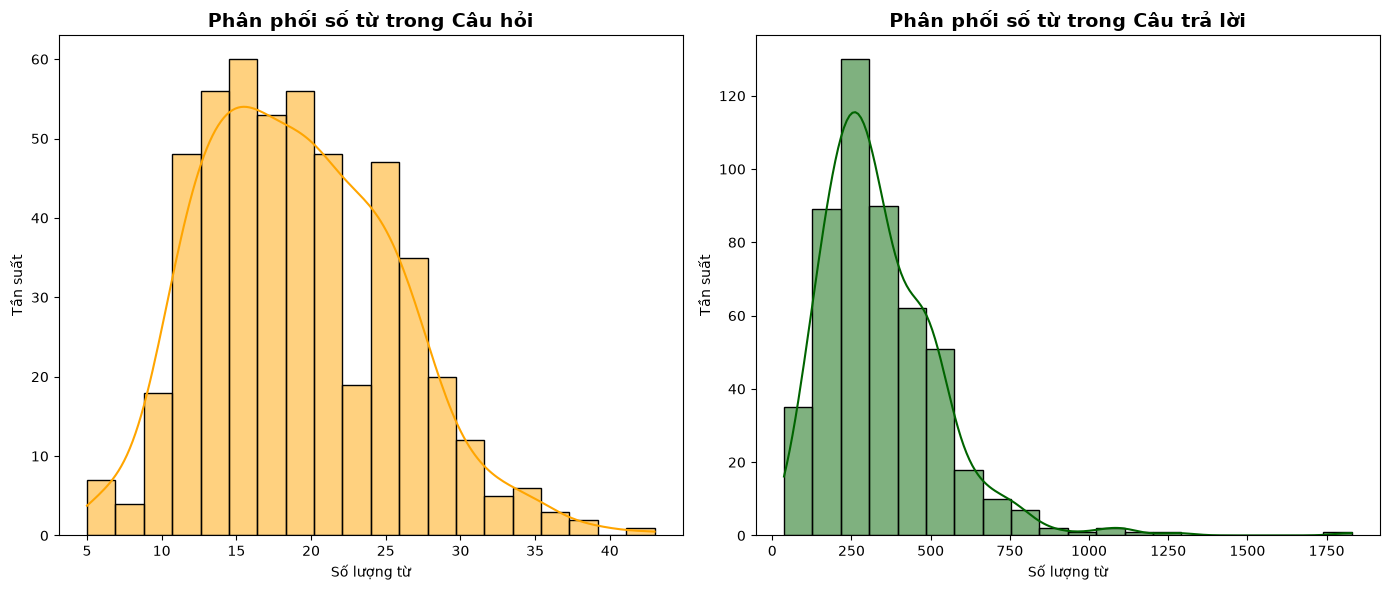

In [17]:
# 5. TRỰC QUAN HÓA
# ==========================================
plt.figure(figsize=(14, 6))

# Biểu đồ phân phối số từ của Câu hỏi (Màu zàng)
plt.subplot(1, 2, 1)
sns.histplot(df['question_word_count'], bins=20, color='#FFA500', kde=True)
plt.title('Phân phối số từ trong Câu hỏi', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')

# Biểu đồ phân phối số từ của Câu trả lời (Màu Deep Green)
plt.subplot(1, 2, 2)
sns.histplot(df['answer_word_count'], bins=20, color='#006400', kde=True)
plt.title('Phân phối số từ trong Câu trả lời', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()

In [18]:
file_path = 'warmup.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Dataframe
if isinstance(data, dict):
    # Trường hợp JSON dạng object lồng nhau: {"id_1": {...}, "id_2": {...}}
    all_records = []
    for key, val in data.items():
        if isinstance(val, dict):
            row = val.copy()
            if 'id' not in row:
                row['id'] = key
            all_records.append(row)
        else:
            all_records.append({'id': key, 'passage': val})
    df = pd.DataFrame(all_records)
elif isinstance(data, list):
    # Trường hợp JSON dạng danh sách: [{"id": 1, "passage": "..."}, ...]
    df = pd.DataFrame(data)

print(f"Đã tải thành công file '{file_path}'! Tổng số bản là: {len(df)}")

Đã tải thành công file 'warmup.json'! Tổng số bản là: 500



--- THỐNG KÊ ĐỘ DÀI CỘT 'question' ---
        question_char_count  question_word_count
min                   21.00                 5.00
max                  193.00                43.00
mean                  85.63                19.15
median                83.00                19.00


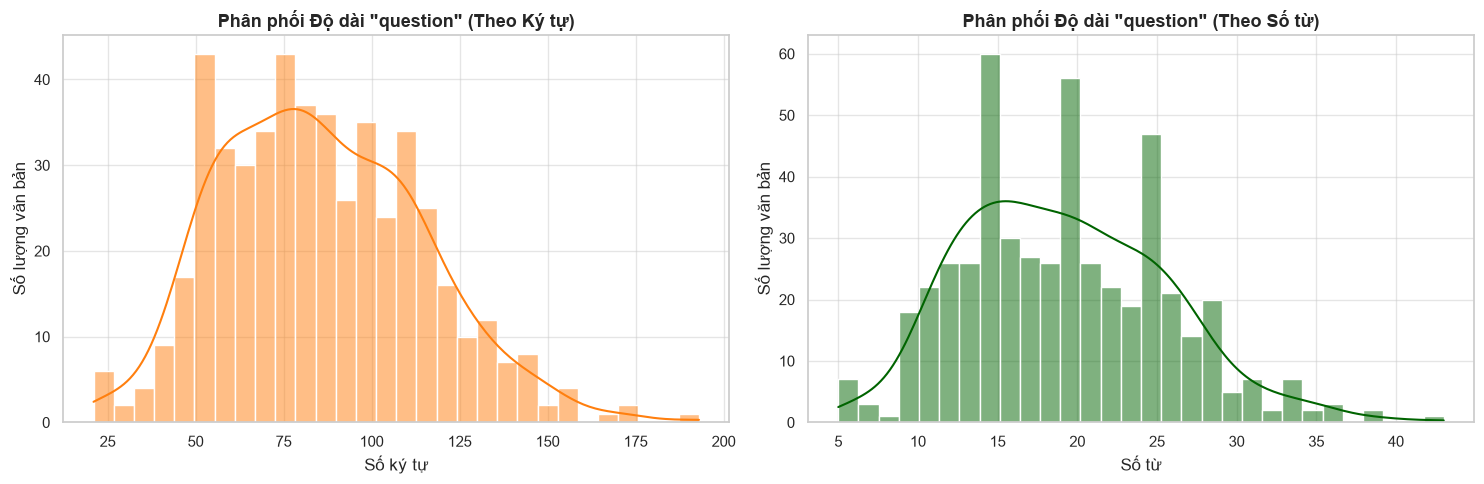


--- THỐNG KÊ ĐỘ DÀI CỘT 'answer' ---
        answer_char_count  answer_word_count
min                176.00              37.00
max               8089.00            1829.00
mean              1556.16             343.18
median            1373.00             303.00


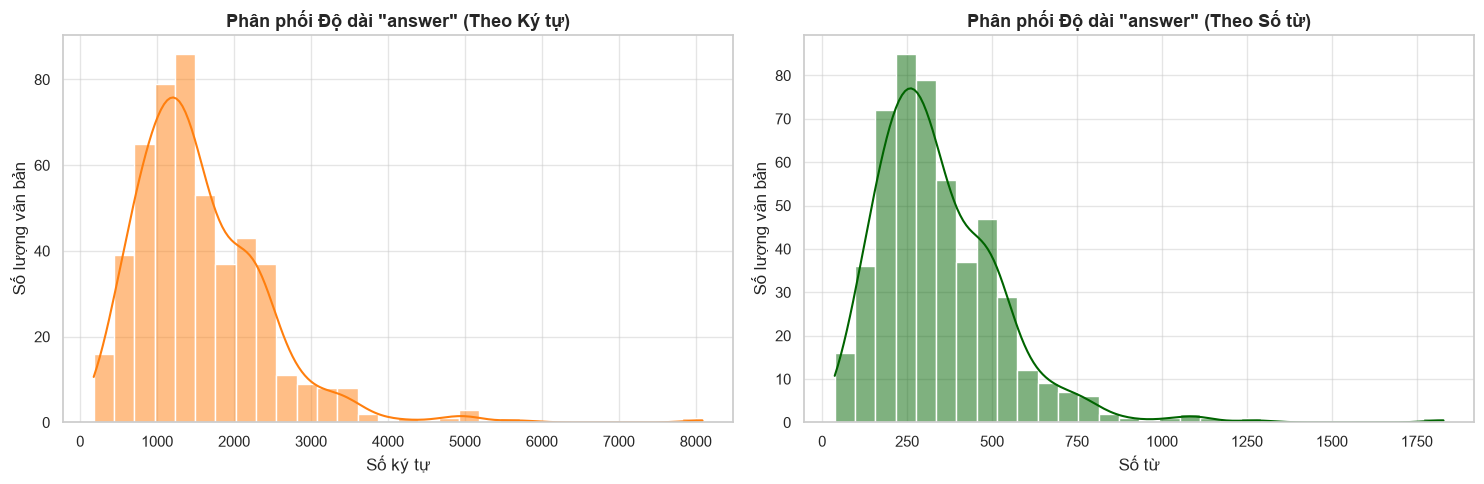

In [21]:
#  Tính toán độ dài văn bản và vẽ biểu đồ phân phối.
# ============================================================
def analyze_text_lengths(df, column):
    texts = df[column].fillna('').astype(str)
    df[f'{column}_char_count'] = texts.apply(len)
    df[f'{column}_word_count'] = texts.apply(lambda text: len(text.split()))

    print(f"\n--- THỐNG KÊ ĐỘ DÀI CỘT '{column}' ---")
    stats = df[[f'{column}_char_count', f'{column}_word_count']].agg(['min', 'max', 'mean', 'median']).round(2)
    print(stats)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(df[f'{column}_char_count'], bins=30, color='#FF7F0E', kde=True, ax=axes[0])
    axes[0].set_title(f'Phân phối Độ dài "{column}" (Theo Ký tự)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Số ký tự')
    axes[0].set_ylabel('Số lượng văn bản')

    sns.histplot(df[f'{column}_word_count'], bins=30, color='#006400', kde=True, ax=axes[1])
    axes[1].set_title(f'Phân phối Độ dài "{column}" (Theo Số từ)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Số từ')
    axes[1].set_ylabel('Số lượng văn bản')

    plt.tight_layout()
    plt.show()

analyze_text_lengths(df, 'question')
analyze_text_lengths(df, 'answer')


In [22]:
# Phân tích kw
# ==========================================
def analyze_keywords(df, column, keywords=['Điều', 'Khoản', 'Nghị định', 'Thông tư']):
    texts = df[column].fillna('').astype(str)

    print(f"\n--- PHÂN TÍCH TỪ KHÓA CẤU TRÚC PHÁP LÝ (cột '{column}') ---")

    for kw in keywords:
        pattern = rf'\b{kw}\b'
        count = texts.apply(lambda text: bool(re.search(pattern, text, flags=re.IGNORECASE))).sum()
        percentage = (count / len(df)) * 100 if len(df) > 0 else 0
        print(f" - Văn bản chứa '{kw}': {count}/{len(df)} ({percentage:.2f}%)")

    combined_pattern = r'\b(' + '|'.join(keywords) + r')\b'
    total_any = texts.apply(lambda text: bool(re.search(combined_pattern, text, flags=re.IGNORECASE))).sum()
    total_any_pct = (total_any / len(df)) * 100 if len(df) > 0 else 0
    print(f" => Văn bản chứa ít nhất 1 từ khóa: {total_any}/{len(df)} ({total_any_pct:.2f}%)")

# Gọi cho từng cột bạn có
analyze_keywords(df, 'question')
analyze_keywords(df, 'answer')


--- PHÂN TÍCH TỪ KHÓA CẤU TRÚC PHÁP LÝ (cột 'question') ---
 - Văn bản chứa 'Điều': 41/500 (8.20%)
 - Văn bản chứa 'Khoản': 9/500 (1.80%)
 - Văn bản chứa 'Nghị định': 4/500 (0.80%)
 - Văn bản chứa 'Thông tư': 0/500 (0.00%)
 => Văn bản chứa ít nhất 1 từ khóa: 53/500 (10.60%)

--- PHÂN TÍCH TỪ KHÓA CẤU TRÚC PHÁP LÝ (cột 'answer') ---
 - Văn bản chứa 'Điều': 473/500 (94.60%)
 - Văn bản chứa 'Khoản': 316/500 (63.20%)
 - Văn bản chứa 'Nghị định': 158/500 (31.60%)
 - Văn bản chứa 'Thông tư': 128/500 (25.60%)
 => Văn bản chứa ít nhất 1 từ khóa: 482/500 (96.40%)


In [27]:
# 1. WORD SEGMENTATION
# ==========================================
import re
from collections import Counter
import pandas as pd
from underthesea import word_tokenize, chunk


def tokenize_column(df, column):
    texts = df[column].fillna('').astype(str)
    return texts.apply(lambda t: word_tokenize(t))  # trả về list token, từ ghép nối bằng "_"


df['question_tokens'] = tokenize_column(df, 'question')
df['answer_tokens'] = tokenize_column(df, 'answer')

print(df[['question', 'question_tokens']].head(3))

                                            question  \
0  Phó chủ tịch công đoàn có được quyền ký thỏa ư...   
1  Trách nhiệm của tổ chức đấu thầu, bảo lãnh, đạ...   
2  Trách nhiệm của các bên liên quan trong việc t...   

                                     question_tokens  
0  [Phó, chủ tịch, công đoàn, có, được, quyền, ký...  
1  [Trách nhiệm, của, tổ chức, đấu thầu, ,, bảo l...  
2  [Trách nhiệm, của, các, bên, liên quan, trong,...  


In [28]:
# 2. HIERARCHICAL CHUNKING
# ==========================================
def extract_phrase_chunks(text):
    if not text or pd.isna(text):
        return []
    tagged = chunk(text)
    chunks, current, cur_type = [], [], None

    for word, pos, tag in tagged:
        if tag.startswith('B-'):
            if current:
                chunks.append((cur_type, ' '.join(current)))
            current, cur_type = [word], tag[2:]
        elif tag.startswith('I-') and cur_type == tag[2:]:
            current.append(word)
        else:
            if current:
                chunks.append((cur_type, ' '.join(current)))
            current, cur_type = [], None
    if current:
        chunks.append((cur_type, ' '.join(current)))
    return chunks

### Test nhanh vài dòng (để dễ control coi data có nang85 ko?)
print(extract_phrase_chunks(df['question'].iloc[0]))
### Full
df['question_chunks'] = df['question'].apply(extract_phrase_chunks)
df['answer_chunks'] = df['answer'].apply(extract_phrase_chunks)


[('NP', 'chủ tịch'), ('NP', 'công đoàn'), ('VP', 'có'), ('NP', 'quyền'), ('VP', 'ký'), ('NP', 'thỏa ước'), ('VP', 'lao động'), ('NP', 'tập thể')]


In [29]:
## TOP 20 TỪ/CỤM TỪ XUẤT HIỆN NHIỀU NHẤT
# ==========================================
def get_ngrams(tokens, n):
    return [' '.join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]


def top_ngrams_all_levels(token_series, max_n=3, top_k=20):
    results = {}
    for n in range(1, max_n + 1):
        counter = Counter()
        for tokens in token_series:
            counter.update(get_ngrams(tokens, n))
        results[n] = counter.most_common(top_k)
    return results


all_tokens = pd.concat([df['question_tokens'], df['answer_tokens']], ignore_index=True)
ngram_results = top_ngrams_all_levels(all_tokens, max_n=3, top_k=20)

for n, top_list in ngram_results.items():
    print(f"\n--- TOP 20 CỤM {n}-GRAM PHỔ BIẾN NHẤT ---")
    for phrase, count in top_list:
        print(f"  {phrase:40s} : {count}")


### Top 20 cụm danh từ phổ biến nhất - ở cấp độ chunk có ngữ nghĩa
def top_chunk_phrases(chunk_series, chunk_type='NP', top_k=20):
    counter = Counter()
    for chunks in chunk_series:
        for ctype, phrase in chunks:
            if ctype == chunk_type:
                counter.update([phrase])
    return counter.most_common(top_k)


all_chunks = pd.concat([df['question_chunks'], df['answer_chunks']], ignore_index=True)

print("\n--- TOP 20 CỤM DANH TỪ PHỔ BIẾN NHẤT ---")
for phrase, count in top_chunk_phrases(all_chunks, 'NP', 20):
    print(f"  {phrase:40s} : {count}")


--- TOP 20 CỤM 1-GRAM PHỔ BIẾN NHẤT ---
  ,                                        : 7841
  .                                        : 3804
  của                                      : 2289
  và                                       : 2049
  quy định                                 : 1916
  được                                     : 1898
  ;                                        : 1887
  có                                       : 1782
  các                                      : 1564
  )                                        : 1514
  theo                                     : 1465
  :                                        : 1410
  -                                        : 1377
  Điều                                     : 1184
  tại                                      : 1115
  về                                       : 1087
  trong                                    : 1049
  người                                    : 1044
  sau                                      : 951
  /       

In [30]:
## TOP 20 TỪ/CỤM TỪ MỞ ĐẦU CÂU HỎI
# ==========================================
def get_starting_ngrams(token_series, n_range=(1, 4), top_k=20):
    results = {}
    for n in range(n_range[0], n_range[1] + 1):
        counter = Counter()
        for tokens in token_series:
            if len(tokens) >= n:
                counter.update([' '.join(tokens[:n])])
        results[n] = counter.most_common(top_k)
    return results


starting_results = get_starting_ngrams(df['question_tokens'], n_range=(1, 4), top_k=20)

for n, top_list in starting_results.items():
    print(f"\n--- TOP 20 CỤM {n} TỪ MỞ ĐẦU CÂU HỎI ---")
    for phrase, count in top_list:
        pct = count / len(df) * 100
        print(f"  {phrase:30s} : {count} ({pct:.2f}%)")


--- TOP 20 CỤM 1 TỪ MỞ ĐẦU CÂU HỎI ---
  Người                          : 21 (4.20%)
  Việc                           : 19 (3.80%)
  Hồ sơ                          : 19 (3.80%)
  Trường hợp                     : 13 (2.60%)
  Cơ quan                        : 13 (2.60%)
  Điều kiện                      : 11 (2.20%)
  Những                          : 10 (2.00%)
  Nội dung                       : 10 (2.00%)
  Ai                             : 10 (2.00%)
  Các                            : 9 (1.80%)
  Để                             : 8 (1.60%)
  Thời gian                      : 8 (1.60%)
  Khi                            : 8 (1.60%)
  Mức                            : 8 (1.60%)
  Công ty                        : 7 (1.40%)
  Nguyên tắc                     : 7 (1.40%)
  Trách nhiệm                    : 6 (1.20%)
  Quyền                          : 6 (1.20%)
  Chủ tịch                       : 6 (1.20%)
  Thời hạn                       : 5 (1.00%)

--- TOP 20 CỤM 2 TỪ MỞ ĐẦU CÂU HỎI ---
  Trường hợ